<a href="https://colab.research.google.com/github/Ishany0/Liver-disease-detection-using-ultrasound-imaging/blob/main/DenseNet121_and_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
path = kagglehub.dataset_download("mahendarbyra/behsof-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'behsof-dataset' dataset.
Path to dataset files: /kaggle/input/behsof-dataset


In [26]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files total)")

behsof-dataset/
  BEHSOF/
    NAFLD/
      nafld_957.jpg
      nafld_222.jpg
      nafld_1467.jpg
      nafld_1120.jpg
      nafld_678.jpg
      ... (1517 files total)
    Non-NAFLD/
      non_nafld_85.jpg
      non_nafld_77.jpg
      non_nafld_0.jpg
      non_nafld_2.jpg
      non_nafld_67.jpg
      ... (152 files total)


In [27]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

src = Path(path) / "BEHSOF"
out = Path("BEHSOF_split")

for cls in ['NAFLD','Non-NAFLD']:
  files = list((src/cls).glob('*.jpg'))
  train , temp = train_test_split(files , test_size = 0.3, random_state = 42)
  dev , test = train_test_split(temp, test_size = 0.5 , random_state = 42)
  for split , flist in zip(['train' , 'dev' , 'test'] , [train , dev , test]):
    d = out / split / cls
    d.mkdir(parents = True , exist_ok = True)
    for f in flist:
      shutil.copy(f,d / f.name)

print("Done: ", out.resolve())

for split in ["train", "dev", "test"]:
    for cls in ["NAFLD", "Non-NAFLD"]:
        d = f"/content/BEHSOF_split/{split}/{cls}"
        print(split, cls, len(os.listdir(d)))

Done:  /content/BEHSOF_split
train NAFLD 1384
train Non-NAFLD 135
dev NAFLD 424
dev Non-NAFLD 45
test NAFLD 421
test Non-NAFLD 42


In [28]:
from tensorflow.keras.applications.densenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.9, 1.1],
    zoom_range=0.05,
)
dev_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = dev_datagen

In [29]:
IMG_SIZE = 224

train_dataset = train_datagen.flow_from_directory(
    "/content/BEHSOF_split/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
)

dev_dataset = dev_datagen.flow_from_directory(
    "/content/BEHSOF_split/dev",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

test_dataset = test_datagen.flow_from_directory(
    "/content/BEHSOF_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

Found 1519 images belonging to 2 classes.
Found 469 images belonging to 2 classes.
Found 463 images belonging to 2 classes.


In [30]:
def binary_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return loss_fn

In [31]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.regularizers import l2

densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
densenet_base.trainable = False

model = Sequential([
    densenet_base,
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(64, activation='relu',kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.build((None, IMG_SIZE, IMG_SIZE, 3))
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,333,313 (27.97 MB)

 Trainable params: 295,553 (1.13 MB)

 Non-trainable params: 7,037,760 (26.85 MB)

None


In [32]:
class Early_Stopping_Callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs=None):
    if logs['loss'] <0.01:
      print('\nLoss is low so cancelling training')
      self.model.stop_training = True


In [33]:
early_stop_phase1 = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', patience=3, factor=0.5, min_lr=1e-6)

In [34]:
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer='adam',
    loss=binary_focal_loss(gamma=2.0, alpha=0.75),  # alpha=0.75 favors the minority (Non-NAFLD) class
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
    ]
)

EPOCHS_PHASE1 = 20

history = model.fit(train_dataset, epochs=EPOCHS_PHASE1, validation_data=dev_dataset ,  callbacks=[Early_Stopping_Callback(), early_stop_phase1, reduce_lr_phase1])

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 405s 8s/step - accuracy: 0.8407 - auc: 0.7854 - loss: 0.0619 - precision: 0.2743 - recall: 0.4815 - val_accuracy: 0.9147 - val_auc: 0.9003 - val_loss: 0.0500 - val_precision: 0.5556 - val_recall: 0.5556 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 384s 8s/step - accuracy: 0.8841 - auc: 0.8532 - loss: 0.0478 - precision: 0.3892 - recall: 0.5333 - val_accuracy: 0.9190 - val_auc: 0.9479 - val_loss: 0.0445 - val_precision: 0.5897 - val_recall: 0.5111 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 373s 8s/step - accuracy: 0.9098 - auc: 0.9144 - loss: 0.0382 - precision: 0.4948 - recall: 0.7037 - val_accuracy: 0.9382 - val_auc: 0.9616 - val_loss: 0.0311 - val_precision: 0.6481 - val_recall: 0.7778 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 381s 8s/step - accuracy: 0.9203 - auc: 0.9447 - loss: 0.0338 - precision: 0.5389 - recall: 0.7185 - val_accuracy: 0.9275 - val_auc: 0.9660 - val_loss: 0.0335 - val_pre

In [35]:
densenet_base.trainable = True
for layer in densenet_base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5,clipnorm=1.0),
    loss=binary_focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

early_stop_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=6, restore_best_weights=True
)
reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-7
)
EPOCHS_PHASE2 = 15
history_finetune= model.fit(train_dataset, epochs=EPOCHS_PHASE2, validation_data=dev_dataset ,  callbacks=[early_stop_phase2, reduce_lr_phase2])

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 484s 10s/step - accuracy: 0.9618 - auc: 0.9927 - loss: 0.0185 - precision: 0.7037 - recall: 0.9852 - val_accuracy: 0.9552 - val_auc: 0.9930 - val_loss: 0.0207 - val_precision: 0.6875 - val_recall: 0.9778 - learning_rate: 1.0000e-05
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.9684 - auc: 0.9918 - loss: 0.0185 - precision: 0.7514 - recall: 0.9630 - val_accuracy: 0.9574 - val_auc: 0.9930 - val_loss: 0.0211 - val_precision: 0.6984 - val_recall: 0.9778 - learning_rate: 1.0000e-05
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 391s 8s/step - accuracy: 0.9724 - auc: 0.9939 - loss: 0.0169 - precision: 0.7818 - recall: 0.9556 - val_accuracy: 0.9595 - val_auc: 0.9931 - val_loss: 0.0204 - val_precision: 0.7097 - val_recall: 0.9778 - learning_rate: 1.0000e-05
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 401s 8s/step - accuracy: 0.9737 - auc: 0.9959 - loss: 0.0159 - precision: 0.7778 - recall: 0.9852 - val_accuracy: 0.9616 - val_auc: 0.9935 - val_loss: 0.0

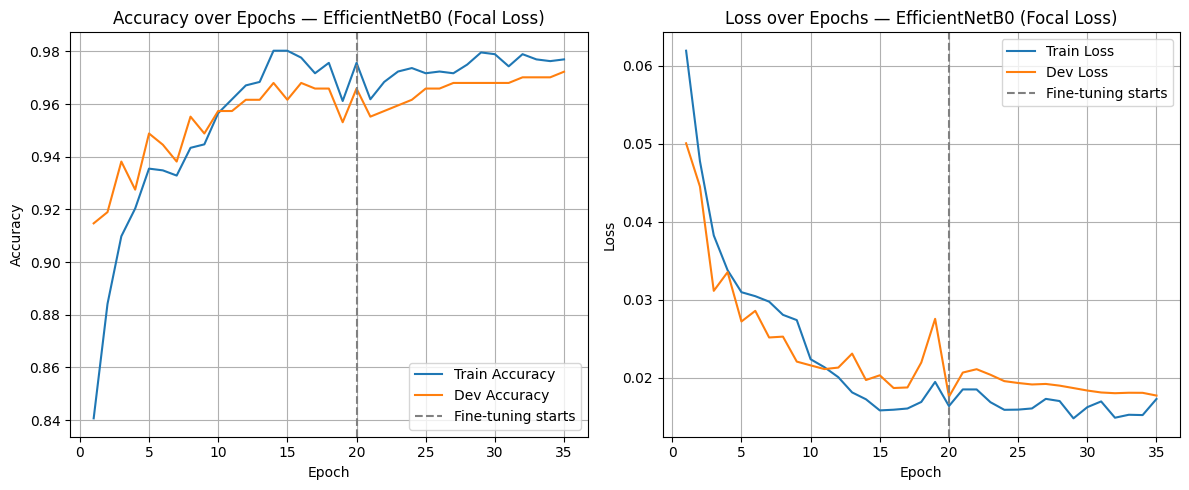

In [36]:
import matplotlib.pyplot as plt


acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']
epochs_range = range(1, len(acc) + 1)
finetune_start = len(history.history['accuracy'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Dev Accuracy')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Accuracy over Epochs — EfficientNetB0 (Focal Loss)'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Dev Loss')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Loss over Epochs — EfficientNetB0 (Focal Loss)'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()



Evaluating on test dataset:
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.9806 - auc: 0.9958 - loss: 0.0162 - precision: 0.8367 - recall: 0.9762
ACCURACY: 0.9805615544319153
LOSS: 0.01619739830493927
15/15 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step
Best threshold (from dev): 0.750 | Best F1 (dev): 0.894
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step

Classification report (test, using dev-tuned threshold):
              precision    recall  f1-score   support

       NAFLD       0.98      1.00      0.99       421
   Non-NAFLD       0.94      0.76      0.84        42

    accuracy                           0.97       463
   macro avg       0.96      0.88      0.91       463
weighted avg       0.97      0.97      0.97       463

AUC score: 0.9958715077479923
Sensitivity (recall, Non-NAFLD): 0.7619047619047619
Specificity (recall, NAFLD): 0.995249406175772


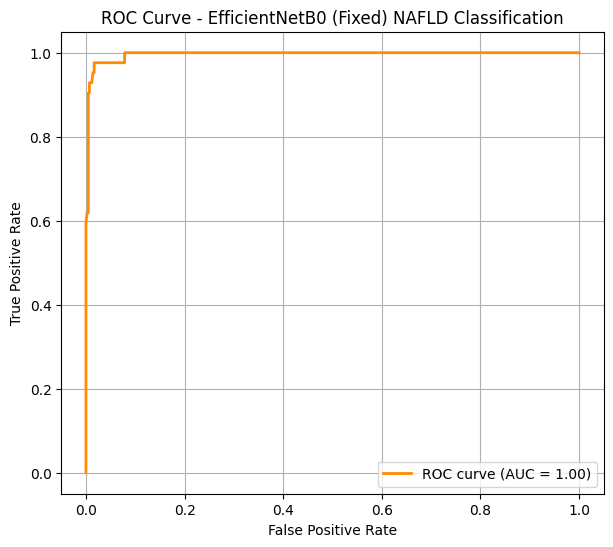

In [37]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

print("Evaluating on test dataset:")
results = model.evaluate(test_dataset)
print("ACCURACY:", results[1])
print("LOSS:", results[0])

dev_dataset.reset()
y_dev_true = dev_dataset.classes
y_dev_prob = model.predict(dev_dataset).ravel()

thresholds = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_dev_true, (y_dev_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1s)]
print(f"Best threshold (from dev): {best_threshold:.3f} | Best F1 (dev): {max(f1s):.3f}")

test_dataset.reset()
y_test_true = test_dataset.classes
y_test_prob = model.predict(test_dataset).ravel()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("\nClassification report (test, using dev-tuned threshold):")
print(classification_report(y_test_true, y_test_pred, target_names=['NAFLD', 'Non-NAFLD']))
print("AUC score:", roc_auc_score(y_test_true, y_test_prob))

cm = confusion_matrix(y_test_true, y_test_pred)
TN, FP, FN, TP = cm.ravel()
print("Sensitivity (recall, Non-NAFLD):", TP / (TP + FN))
print("Specificity (recall, NAFLD):", TN / (TN + FP))

fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
auc_score = roc_auc_score(y_test_true, y_test_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNetB0 (Fixed) NAFLD Classification')
plt.grid(True); plt.show()
